In [1]:
from collections import deque
import math
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def compute_next_price_move(data):
    # next price move (npm) is 1 if the price goes up, 0 if price goes down
    npm=1
    n=len(data)
    data['npm']=0
    for i in range(0,n):
        if data['dMid'][n-i-1]==0.0:
            data.iloc[n-i-1, data.columns.get_loc('npm')]=npm
        else:
            npm=(1+np.sign(data['dMid'][n-i-1]))/2
            data.iloc[n-i-1, data.columns.get_loc('npm')]=npm
    return data


def plot_prob_up(data,granularity,title, col):
    # Bin Imbalance_Multi into 10 equal-width groups
    data = data.copy()
    data[col] = pd.cut(data[col], bins=10)
    # Compute mean npm per bin
    grouped = data.groupby(col, observed=True)
    res = grouped['npm'].mean()
    # Use bin midpoints as x-axis
    bin_midpoints = [interval.mid for interval in res.index]
    plt.figure(figsize=(8, 5))
    plt.plot(bin_midpoints, res.values, '*-')
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel('Probability of up-move')
    plt.tight_layout()
    plt.show()
    return res

In [13]:
PARAMS = {
    # rolling window
    "short_window": "1s",
    "mid_window": "5s",
    "long_window": "15s"
}

def load_lob_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Parse time with dummy date
    df["dt"] = pd.to_datetime("2026-01-01 " + df["Time"].astype(str), format="%Y-%m-%d %H:%M:%S.%f")
    df = df.sort_values("dt").reset_index(drop=True)
    # minute bucket
    df["minute"] = df["dt"].dt.floor("min")
    # seconds within minute
    df["sec_in_min"] = (
        df["dt"].dt.second
        + df["dt"].dt.microsecond / 1_000_000
    )
    return df

def add_queue_toxicity_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Depth features

    bid_size_cols = [f"BidSize_{i}" for i in range(1, 6)]
    ask_size_cols = [f"AskSize_{i}" for i in range(1, 6)]

    out["BidDepth_1"] = out["BidSize_1"]
    out["AskDepth_1"] = out["AskSize_1"]
    out["BidDepth_5"] = out[bid_size_cols].sum(axis=1)
    out["AskDepth_5"] = out[ask_size_cols].sum(axis=1)

    out["Imbalance_1"] = (out["BidSize_1"] - out["AskSize_1"]) / (
        out["BidSize_1"] + out["AskSize_1"] + 1e-9
    )
    out["Imbalance_5"] = (out["BidDepth_5"] - out["AskDepth_5"]) / (
        out["BidDepth_5"] + out["AskDepth_5"] + 1e-9
    )

    # Mid / Microprice
    out["MidPrice"] = (out["BidPrice_1"] + out["AskPrice_1"]) / 2.0

    out["MicroPrice"] = (
        out["AskPrice_1"] * out["BidSize_1"] + out["BidPrice_1"] * out["AskSize_1"]
    ) / (out["BidSize_1"] + out["AskSize_1"] + 1e-9)

    # micro_edge > 0 means microprice above mid => upward pressure
    out["MicroEdge"] = out["MicroPrice"] - out["MidPrice"]
    vis = out["VisibleExecution_1=Yes_0=No"]
    hid = out["HiddenExecution_1=Yes_0=No"]
    out['TFI'] = 0
    for el in range(len(vis)):
      if vis[el] == 1 or hid[el] == 1:
          direction = out["Direction_1=Buy_-1=Sell"][el]
          size = out["Size"][el]
          out.loc[el, "TFI"] = direction * size/(out["BidSize_1"][el] + out["AskSize_1"][el])
    out['Rolling_TFI'] = out['TFI'].rolling(window=100, min_periods=1).mean().shift(1).fillna(0)
    out['Rolling_std_TFI'] = out['TFI'].rolling(window=100, min_periods=1).std().shift(1).fillna(0)
    # Basic changes
    out["dMid"] = out["MidPrice"].diff()
    out["dSpread"] = out["Spread"].diff()
    out["dBidDepth_1"] = out["BidDepth_1"].diff()
    out["dAskDepth_1"] = out["AskDepth_1"].diff()
    out["dBidDepth_5"] = out["BidDepth_5"].diff()
    out["dAskDepth_5"] = out["AskDepth_5"].diff()

    out["BidQuoteChange"] = (out["BidPrice_1"] != out["BidPrice_1"].shift(1)).astype(int)
    out["AskQuoteChange"] = (out["AskPrice_1"] != out["AskPrice_1"].shift(1)).astype(int)
    out["QuoteChange"] = ((out["BidQuoteChange"] == 1) | (out["AskQuoteChange"] == 1)).astype(int)

    # Event signed flows
    # Direction_1=Buy_-1=Sell:
    #   +1 means buyer-initiated
    #   -1 means seller-initiated
    dir_col = "Direction_1=Buy_-1=Sell"

    visible_exec = out["VisibleExecution_1=Yes_0=No"].fillna(0)
    hidden_exec = out["HiddenExecution_1=Yes_0=No"].fillna(0)
    new_limit = out["NewLimitOrder_1=Yes_0=No"].fillna(0)
    partial_cancel = out["PartialCancel_1=Yes_0=No"].fillna(0)
    full_delete = out["FullDelete_1=Yes_0=No"].fillna(0)
    cancel_flag = ((partial_cancel == 1) | (full_delete == 1)).astype(int)

    out["VisibleExecSize"] = visible_exec * out["Size"].fillna(0)
    out["HiddenExecSize"] = hidden_exec * out["Size"].fillna(0)
    out["TotalExecSize"] = out["VisibleExecSize"] + out["HiddenExecSize"]

    out["SignedExecFlow"] = out["TotalExecSize"] * out[dir_col].fillna(0)
    out["BuyExecFlow"] = np.where(out[dir_col] == 1, out["TotalExecSize"], 0.0)
    out["SellExecFlow"] = np.where(out[dir_col] == -1, out["TotalExecSize"], 0.0)

    # New limit order flow (rough proxy)
    out["SignedNewLimitFlow"] = new_limit * out["Size"].fillna(0) * out[dir_col].fillna(0)

    # Cancel pressure proxies
    out["SignedCancelFlow"] = cancel_flag * out["Size"].fillna(0) * out[dir_col].fillna(0)
    out["BuyCancelFlow"] = np.where((cancel_flag == 1) & (out[dir_col] == 1), out["Size"].fillna(0), 0.0)
    out["SellCancelFlow"] = np.where((cancel_flag == 1) & (out[dir_col] == -1), out["Size"].fillna(0), 0.0)

    # Ask-side instability proxy:
    # buy-initiated executions + sell-side quote deterioration + ask-side cancel-like pressure
    # Since event-side mapping is not perfect from raw data, we use a practical proxy:
    out["AskCancelProxy"] = np.where(
        (cancel_flag == 1) & (out[dir_col] == -1), out["Size"].fillna(0), 0.0
    )
    out["BidCancelProxy"] = np.where(
        (cancel_flag == 1) & (out[dir_col] == 1), out["Size"].fillna(0), 0.0
    )


    # Time-based rolling features
    # shift(1) after computation to ensure point-in-time
    out = out.set_index("dt")

    roll_cols = [
        "SignedExecFlow", "BuyExecFlow", "SellExecFlow",
        "SignedNewLimitFlow", "SignedCancelFlow",
        "AskCancelProxy", "BidCancelProxy",
        "QuoteChange",
        "dMid", "dSpread",
        "BidDepth_1", "AskDepth_1",
        "BidDepth_5", "AskDepth_5",
        "Imbalance_1", "Imbalance_5",
        "MicroEdge"
    ]

    for w in [PARAMS["short_window"], PARAMS["mid_window"], PARAMS["long_window"]]:
        out[f"ExecImb_{w}"] = (
            out["SignedExecFlow"].rolling(w, min_periods=1).sum()
            / (out["TotalExecSize"].rolling(w, min_periods=1).sum() + 1e-9)
        )

        out[f"BuyExecFlow_{w}"] = out["BuyExecFlow"].rolling(w, min_periods=1).sum()
        out[f"SellExecFlow_{w}"] = out["SellExecFlow"].rolling(w, min_periods=1).sum()

        out[f"AskCancel_{w}"] = out["AskCancelProxy"].rolling(w, min_periods=1).sum()
        out[f"BidCancel_{w}"] = out["BidCancelProxy"].rolling(w, min_periods=1).sum()

        out[f"QuoteInstability_{w}"] = out["QuoteChange"].rolling(w, min_periods=1).sum()

        out[f"MicroEdgeMean_{w}"] = out["MicroEdge"].rolling(w, min_periods=1).mean()
        out[f"MidRV_{w}"] = out["dMid"].pow(2).rolling(w, min_periods=1).sum()
        out[f"SpreadMean_{w}"] = out["Spread"].rolling(w, min_periods=1).mean()

        out[f"BidDepth1Mean_{w}"] = out["BidDepth_1"].rolling(w, min_periods=1).mean()
        out[f"AskDepth1Mean_{w}"] = out["AskDepth_1"].rolling(w, min_periods=1).mean()
        out[f"BidDepth5Mean_{w}"] = out["BidDepth_5"].rolling(w, min_periods=1).mean()
        out[f"AskDepth5Mean_{w}"] = out["AskDepth_5"].rolling(w, min_periods=1).mean()

        out[f"Imb1Mean_{w}"] = out["Imbalance_1"].rolling(w, min_periods=1).mean()
        out[f"Imb5Mean_{w}"] = out["Imbalance_5"].rolling(w, min_periods=1).mean()

    # shift all state features by 1 event to avoid leakage
    feature_cols_to_shift = [
        "Spread", "MidPrice", "MicroPrice", "MicroEdge",
        "BidDepth_1", "AskDepth_1", "BidDepth_5", "AskDepth_5",
        "Imbalance_1", "Imbalance_5",
        "dMid", "dSpread", "dBidDepth_1", "dAskDepth_1", "dBidDepth_5", "dAskDepth_5",
        "BidQuoteChange", "AskQuoteChange", "QuoteChange",
        "SignedExecFlow", "BuyExecFlow", "SellExecFlow",
        "SignedNewLimitFlow", "SignedCancelFlow",
        "AskCancelProxy", "BidCancelProxy"
    ] + [c for c in out.columns if any(c.endswith(f"_{w}") for w in [PARAMS["short_window"], PARAMS["mid_window"], PARAMS["long_window"]])]

    feature_cols_to_shift = list(dict.fromkeys(feature_cols_to_shift))  # dedupe
    out[feature_cols_to_shift] = out[feature_cols_to_shift].shift(1)

    out = out.reset_index()

    # restore minute / sec_in_min if lost
    out["minute"] = out["dt"].dt.floor("min")
    out["sec_in_min"] = out["dt"].dt.second + out["dt"].dt.microsecond / 1_000_000

    # drop first row if many NaNs
    return out

In [14]:
a = load_lob_csv('../data/AMZN_5levels_train.csv')
a = add_queue_toxicity_features(a)
m = load_lob_csv('../data/MSFT_5levels_train.csv')
m = add_queue_toxicity_features(m)
i = load_lob_csv('../data/INTC_5levels_train.csv')
i = add_queue_toxicity_features(i)
g = load_lob_csv('../data/GOOG_5levels_train.csv')
g = add_queue_toxicity_features(g)

In [15]:
a = compute_next_price_move(a)
m = compute_next_price_move(m)
i = compute_next_price_move(i)
g = compute_next_price_move(g)

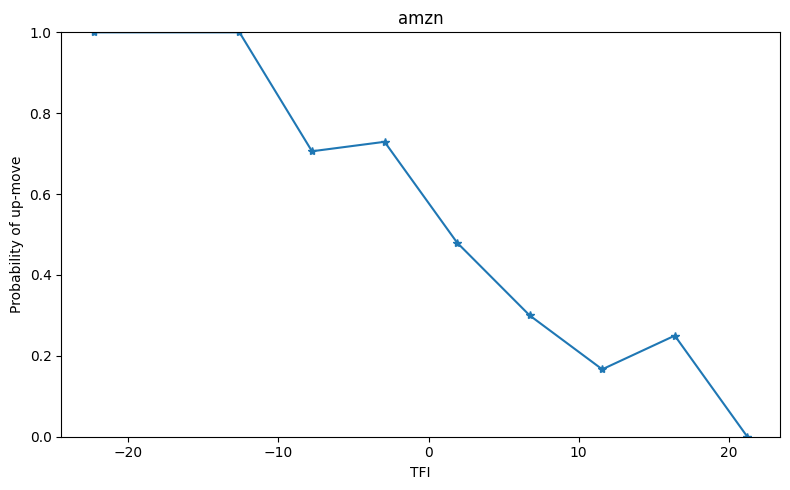

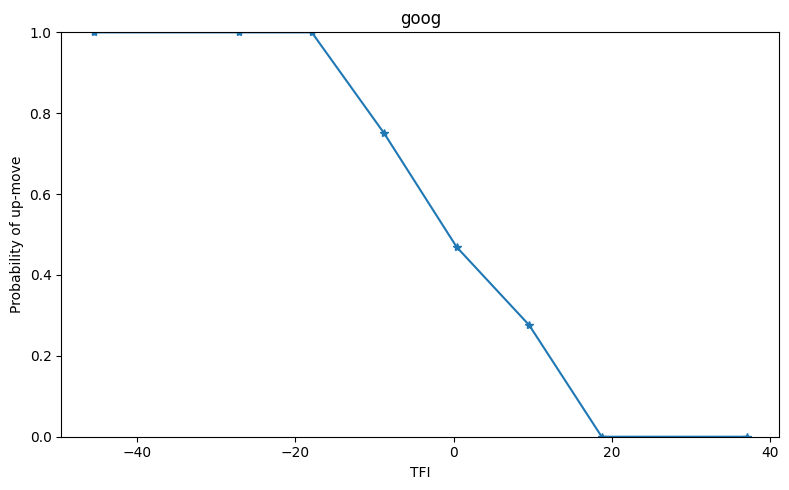

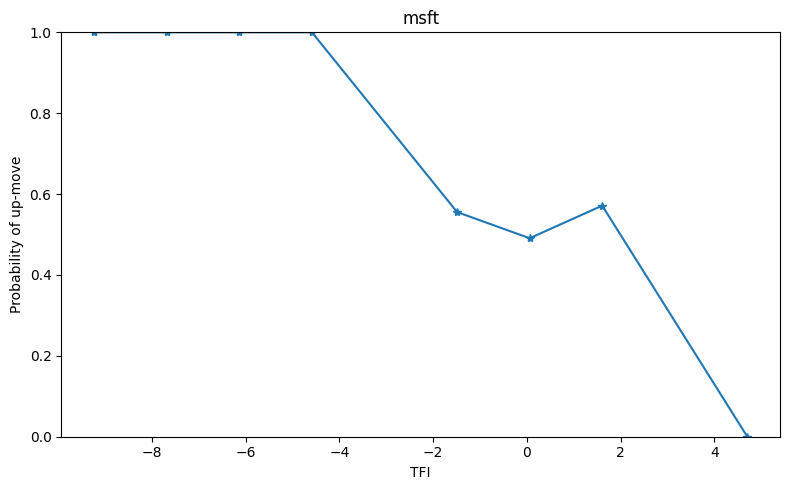

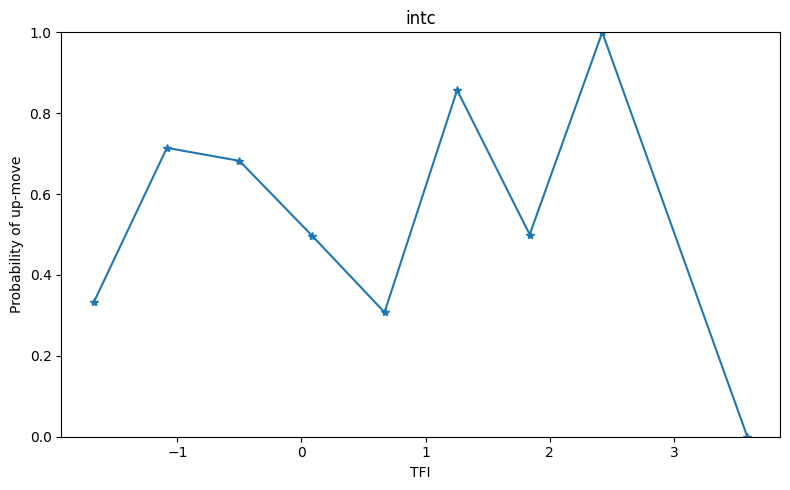

In [ ]:
col = 'TFI' 
pup_amzn=plot_prob_up(a,10,'amzn',col)
pup_goog=plot_prob_up(g,10,'goog',col)
pup_msft=plot_prob_up(m,10,'msft',col)
pup_intc=plot_prob_up(i,10,'intc',col)

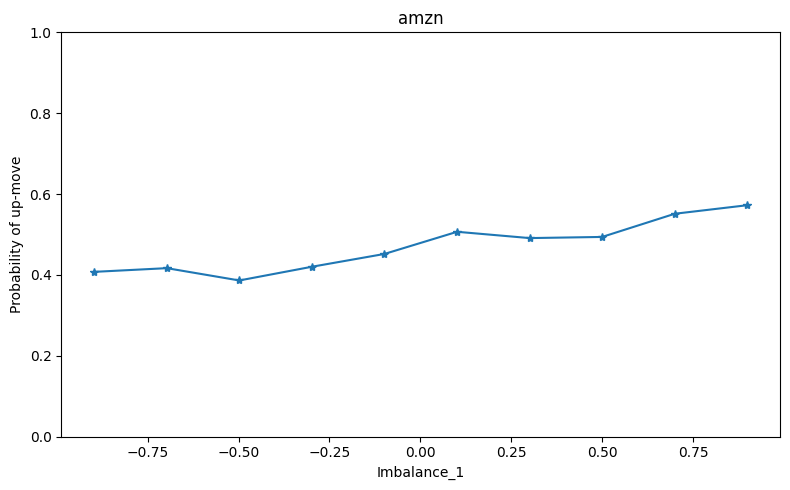

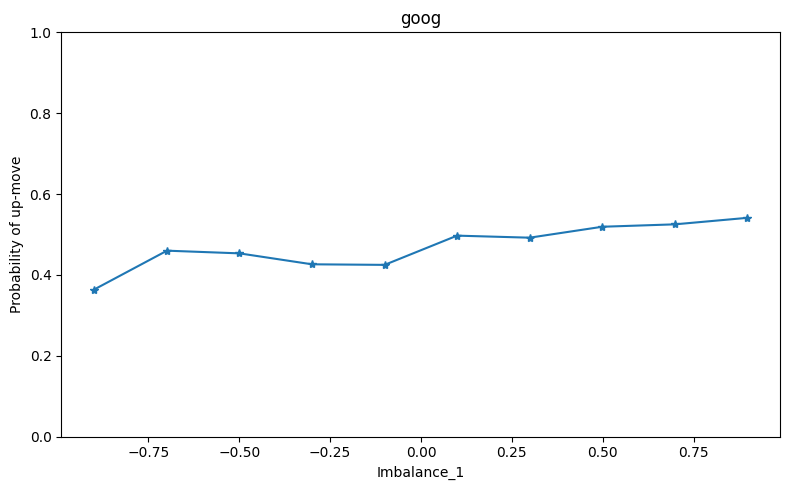

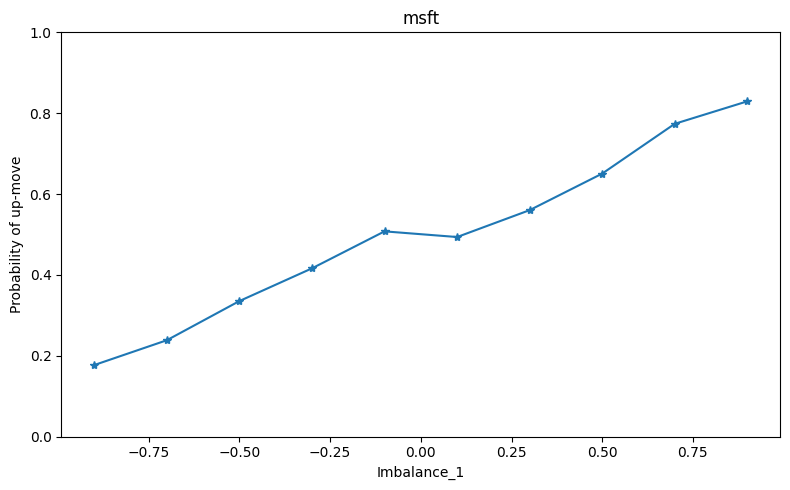

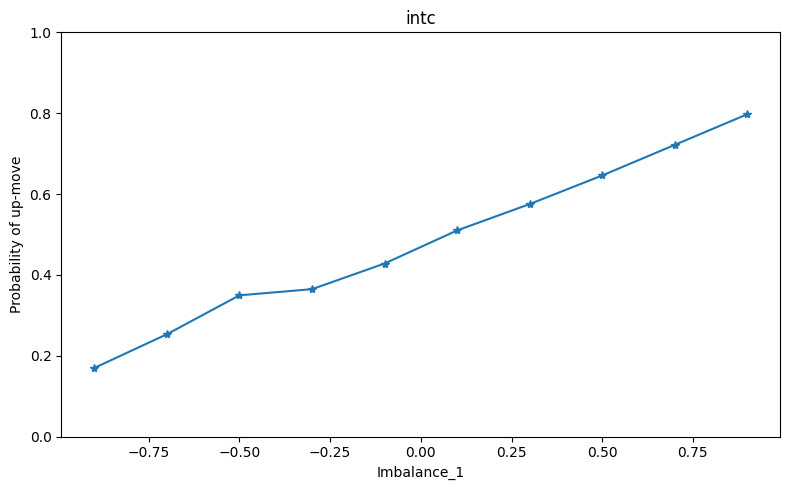

In [22]:
col = 'Imbalance_1' 
pup_amzn=plot_prob_up(a,10,'amzn',col)
pup_goog=plot_prob_up(g,10,'goog',col)
pup_msft=plot_prob_up(m,10,'msft',col)
pup_intc=plot_prob_up(i,10,'intc',col)